In [25]:
import gymnasium as gym
import imageio
from pathlib import Path
import base64
from IPython.display import HTML

# Crear ambiente
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Inicializar ambiente
observation, info = env.reset()

# Variables
frames = []
total_reward = 0
num_steps = 200

# Agente aleatorio durante exactamente 200 pasos
for step in range(num_steps):
    # Guardar frame actual
    frame = env.render()
    frames.append(frame)

    # Acción aleatoria
    action = env.action_space.sample()

    # Ejecutar acción
    observation, reward, terminated, truncated, info = env.step(action)

    # Acumular recompensa total
    total_reward += reward

env.close()

print("Pasos ejecutados:", num_steps)
print("Recompensa total:", total_reward)
print("Frames guardados:", len(frames))

Pasos ejecutados: 200
Recompensa total: 41.0
Frames guardados: 200


In [26]:
# Guardar video
video_path = Path("agente_aleatorio_cartpole.mp4")

imageio.mimsave(video_path, frames, fps=30)

print("Video guardado en:", video_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video guardado en: agente_aleatorio_cartpole.mp4


In [27]:
# Leer video como bytes
video_bytes = video_path.read_bytes()

# Codificar en base64
video_base64 = base64.b64encode(video_bytes).decode("utf-8")

# Mostrar video en HTML
HTML(f"""
<video width="600" controls>
    <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
</video>
""")

In [28]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

# Crear ambiente sin render, porque no vamos a generar video ni mostrar frames
env = gym.make("CartPole-v1")

# Número de episodios
num_episodes = 1000

# Lista para almacenar la recompensa total de cada episodio
episode_rewards = []

# Ejecutar agente aleatorio durante 1000 episodios
for episode in range(num_episodes):
    
    # Reiniciar ambiente al inicio de cada episodio
    observation, info = env.reset()
    
    # Variables del episodio
    done = False
    total_reward = 0
    
    # Ejecutar hasta que el experimento falle o termine
    while not done:
        
        # Seleccionar acción aleatoria
        action = env.action_space.sample()
        
        # Ejecutar acción en el ambiente
        observation, reward, terminated, truncated, info = env.step(action)
        
        # Acumular recompensa del episodio
        total_reward += reward
        
        # Definir si el episodio terminó
        done = terminated or truncated
    
    # Guardar recompensa total del episodio
    episode_rewards.append(total_reward)

env.close()

print("Episodios ejecutados:", num_episodes)
print("Recompensa promedio:", np.mean(episode_rewards))
print("Recompensa mínima:", np.min(episode_rewards))
print("Recompensa máxima:", np.max(episode_rewards))

Episodios ejecutados: 1000
Recompensa promedio: 22.267
Recompensa mínima: 8.0
Recompensa máxima: 121.0


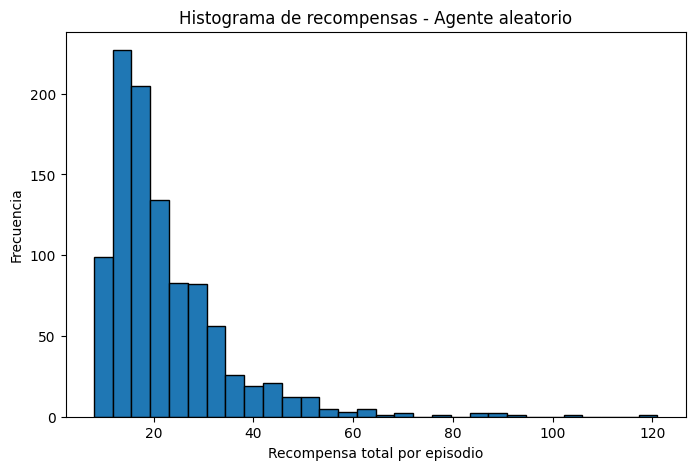

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(episode_rewards, bins=30, edgecolor="black")

plt.title("Histograma de recompensas - Agente aleatorio")
plt.xlabel("Recompensa total por episodio")
plt.ylabel("Frecuencia")

plt.show()